# Preprocessing

This notebook transforms the raw transaction-level data into a customer-level feature matrix for clustering. It removes cancellations and invalid records, engineers RFM (Recency, Frequency, Monetary) features along with additional behavioral features, and saves the result to S3.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## Helper Classes

In [2]:
class Preprocessing:
    def __init__(self, str_uri_import, str_uri_export, str_dirname_output):
        self.str_uri_import = str_uri_import
        self.str_uri_export = str_uri_export
        self.str_dirname_output = str_dirname_output

    def import_data(self):
        df = pd.read_parquet(self.str_uri_import)
        df['invoicedate'] = pd.to_datetime(df['invoicedate'], errors='coerce')
        df.sort_values(by='invoicedate', ascending=True, inplace=True)
        print(f'Raw rows: {df.shape[0]:,}')
        self.df = df

    def clean_data(self):
        df = self.df.copy()
        int_start = df.shape[0]

        # remove cancellations (invoices starting with 'C')
        df = df[~df['invoice'].astype(str).str.startswith('C')].copy()
        print(f'After removing cancellations: {df.shape[0]:,} ({int_start - df.shape[0]:,} removed)')

        # remove rows with missing customer_id
        int_before = df.shape[0]
        df = df[df['customer_id'].notna()].copy()
        print(f'After removing missing customer_id: {df.shape[0]:,} ({int_before - df.shape[0]:,} removed)')

        # remove rows with quantity <= 0
        int_before = df.shape[0]
        df = df[df['quantity'] > 0].copy()
        print(f'After removing quantity <= 0: {df.shape[0]:,} ({int_before - df.shape[0]:,} removed)')

        # remove rows with price <= 0
        int_before = df.shape[0]
        df = df[df['price'] > 0].copy()
        print(f'After removing price <= 0: {df.shape[0]:,} ({int_before - df.shape[0]:,} removed)')

        # compute revenue
        df['revenue'] = df['quantity'] * df['price']

        print(f'\nTotal removed: {int_start - df.shape[0]:,} ({(int_start - df.shape[0]) / int_start:.2%})')
        print(f'Remaining rows: {df.shape[0]:,}')
        self.df_clean = df

    def engineer_features(self):
        df = self.df_clean.copy()
        dtm_reference = df['invoicedate'].max() + pd.Timedelta(days=1)
        print(f'Reference date: {dtm_reference}')

        # RFM features
        df_rfm = df.groupby(by='customer_id', as_index=False).agg(
            recency=('invoicedate', lambda x: (dtm_reference - x.max()).days),
            frequency=('invoice', 'nunique'),
            monetary=('revenue', 'sum'),
        )

        # additional behavioral features
        df_behavior = df.groupby(by='customer_id', as_index=False).agg(
            avg_order_value=('revenue', lambda x: x.groupby(df.loc[x.index, 'invoice']).sum().mean()),
            avg_items_per_order=('quantity', lambda x: x.groupby(df.loc[x.index, 'invoice']).sum().mean()),
            unique_products=('stockcode', 'nunique'),
            avg_unit_price=('price', 'mean'),
            tenure_days=('invoicedate', lambda x: (x.max() - x.min()).days),
        )

        # merge
        df_customers = df_rfm.merge(df_behavior, on='customer_id', how='left')

        print(f'Customers: {df_customers.shape[0]:,}')
        print(f'Features: {df_customers.shape[1] - 1}')
        self.df_customers = df_customers

    def plot_feature_distributions(self):
        list_features = [
            'recency', 'frequency', 'monetary', 'avg_order_value',
            'avg_items_per_order', 'unique_products', 'avg_unit_price', 'tenure_days',
        ]
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        fig.suptitle('Customer Feature Distributions (Clipped at 99th Percentile)', fontsize=16, y=1.02)
        for idx, col in enumerate(list_features):
            row, col_idx = divmod(idx, 4)
            ax = axes[row][col_idx]
            p99 = self.df_customers[col].quantile(0.99)
            ser_clipped = self.df_customers[col].clip(upper=p99)
            ax.hist(ser_clipped, bins=50, color='tab:blue', alpha=0.7, edgecolor='black', linewidth=0.3)
            ax.axvline(ser_clipped.median(), color='tab:red', linestyle='--',
                       label=f'Median: {self.df_customers[col].median():.1f}')
            ax.set_title(col)
            ax.set_ylabel('Frequency')
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/feature_distributions.png', bbox_inches='tight', dpi=150)
        plt.show()

    def plot_correlation_heatmap(self):
        list_features = [
            'recency', 'frequency', 'monetary', 'avg_order_value',
            'avg_items_per_order', 'unique_products', 'avg_unit_price', 'tenure_days',
        ]
        df_corr = self.df_customers[list_features].corr()
        mask = np.triu(np.ones_like(df_corr, dtype=bool))
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.set_title('Feature Correlation Heatmap')
        sns.heatmap(df_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, vmin=-1, vmax=1, square=True, ax=ax,
                    linewidths=0.5, cbar_kws={'shrink': 0.8})
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/correlation_heatmap.png', bbox_inches='tight', dpi=150)
        plt.show()

    def plot_summary_table(self):
        list_features = [
            'recency', 'frequency', 'monetary', 'avg_order_value',
            'avg_items_per_order', 'unique_products', 'avg_unit_price', 'tenure_days',
        ]
        df_desc = self.df_customers[list_features].describe().T
        df_desc.to_csv(f'{self.str_dirname_output}/feature_summary.csv')
        print(f'Saved feature summary to {self.str_dirname_output}/feature_summary.csv')
        return df_desc

    def save_data(self):
        self.df_customers.to_parquet(self.str_uri_export, index=False)
        print(f'Saved {self.df_customers.shape[0]:,} customers to {self.str_uri_export}')

## Constants

In [3]:
str_bucket = 'cluster-analysis-demo'
print(f'Bucket: {str_bucket}')

str_task = '02_preprocessing'
print(f'Task: {str_task}')

str_dirname_output = './output'

# data uri - import
str_uri_import = f's3://{str_bucket}/00_data_collection/data.parquet'

# data uri - export
str_uri_export = f's3://{str_bucket}/{str_task}/df_customers.parquet'

Bucket: cluster-analysis-demo
Task: 02_preprocessing


## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Initialize Preprocessing Class

In [5]:
cls_prep = Preprocessing(
    str_uri_import=str_uri_import,
    str_uri_export=str_uri_export,
    str_dirname_output=str_dirname_output,
)

## Import Data

In [6]:
cls_prep.import_data()
cls_prep.df.head()

Raw rows: 525,461


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Clean Data

In [7]:
cls_prep.clean_data()

After removing cancellations: 515,255 (10,206 removed)
After removing missing customer_id: 407,695 (107,560 removed)
After removing quantity <= 0: 407,695 (0 removed)
After removing price <= 0: 407,664 (31 removed)

Total removed: 117,797 (22.42%)
Remaining rows: 407,664


## Engineer Customer-Level Features

In [8]:
cls_prep.engineer_features()
cls_prep.df_customers.head()

Reference date: 2010-12-10 20:01:00
Customers: 4,312
Features: 8


,customer_id,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,avg_unit_price,tenure_days
0,12346.0,165,11,372.86,33.896364,6.363636,26,6.253333,196
1,12347.0,3,2,1323.32,661.660000,414.000000,70,2.295070,37
2,12348.0,74,1,222.16,222.160000,373.000000,20,0.719500,0
3,12349.0,43,3,2671.14,890.380000,331.000000,90,8.581765,181
4,12351.0,11,1,300.93,300.930000,261.000000,21,2.355238,0


## Feature Summary

In [9]:
cls_prep.plot_summary_table()

Saved feature summary to ./output/feature_summary.csv


,count,mean,std,min,25%,50%,75%,max
recency,4312.0,91.171846,96.860633,1.000000,18.000000,53.000000,136.000000,374.00
frequency,4312.0,4.455705,8.170213,1.000000,1.000000,2.000000,5.000000,205.00
monetary,4312.0,2048.238236,8914.481280,2.950000,307.987500,706.020000,1723.142500,349164.35
avg_order_value,4312.0,378.322627,492.564076,2.950000,182.087857,287.368056,423.576667,11880.84
avg_items_per_order,4312.0,255.751540,1554.107975,1.000000,90.000000,151.916667,257.000000,87167.00
unique_products,4312.0,63.646104,85.757966,1.000000,17.000000,38.000000,79.250000,1741.00
avg_unit_price,4312.0,9.861774,203.373547,0.151333,2.302476,2.970595,3.881839,10953.50
tenure_days,4312.0,133.998609,132.827183,0.000000,0.000000,105.000000,254.000000,373.00


## Feature Distributions

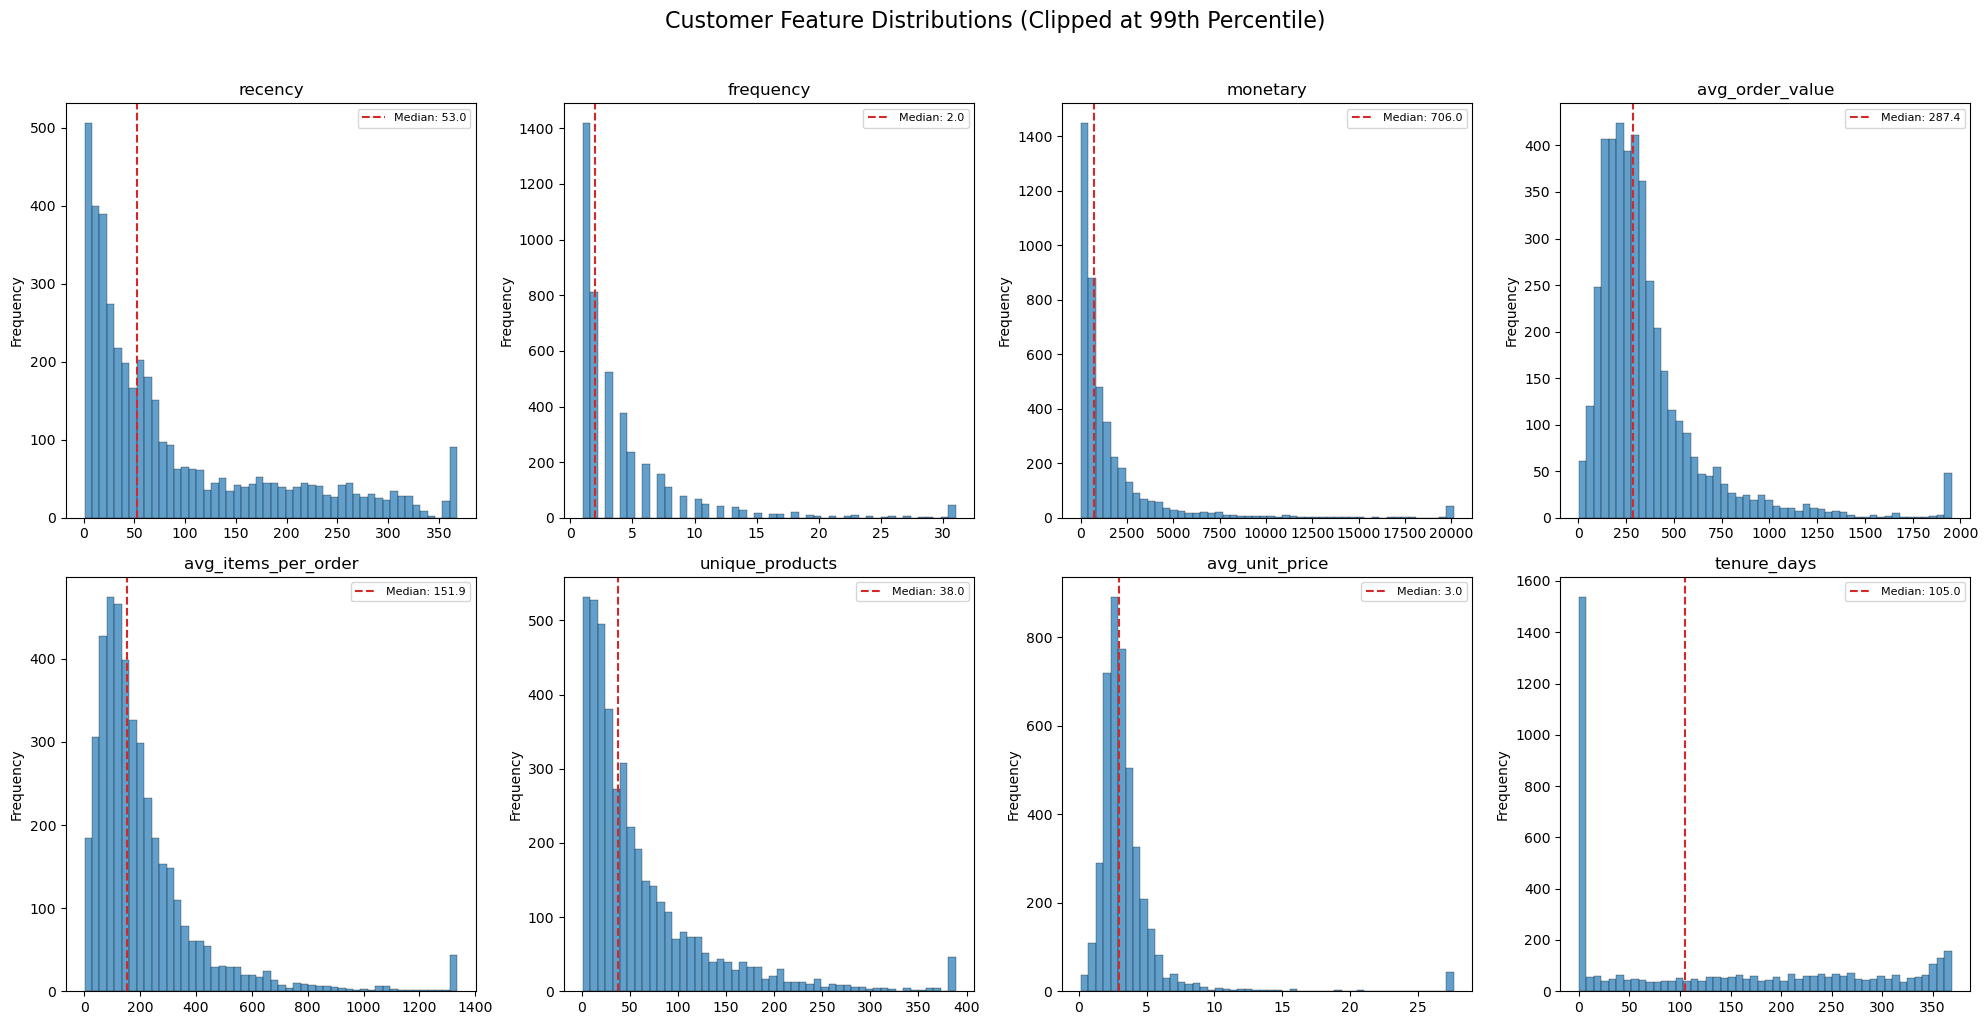

In [10]:
cls_prep.plot_feature_distributions()

## Feature Correlation Heatmap

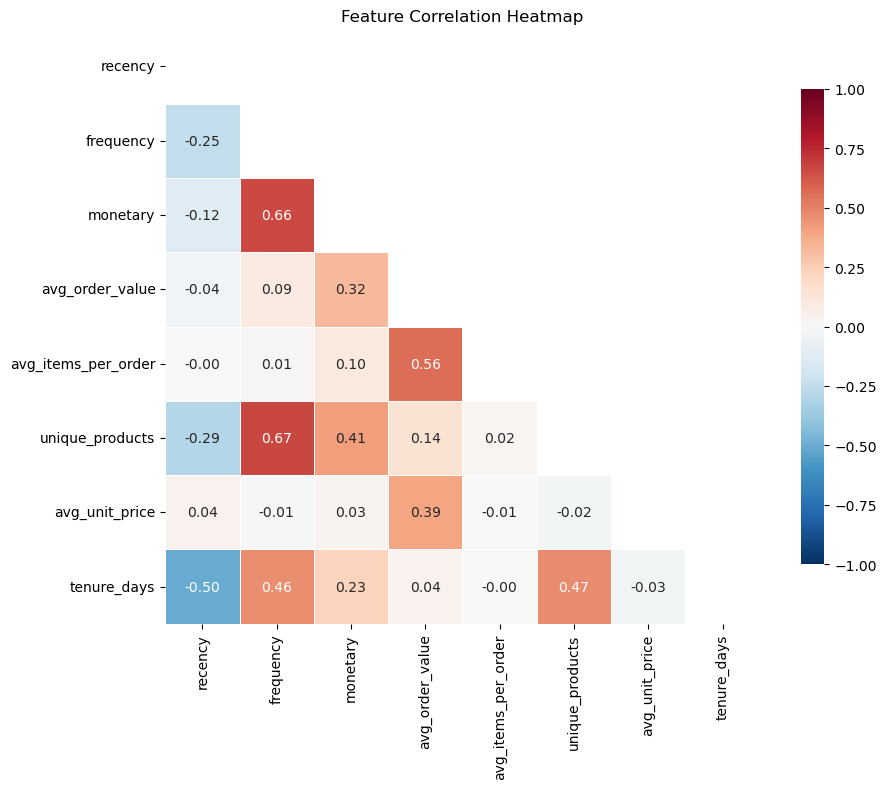

In [11]:
cls_prep.plot_correlation_heatmap()

## Save Customer-Level Data to S3

In [12]:
cls_prep.save_data()

Saved 4,312 customers to s3://cluster-analysis-demo/02_preprocessing/df_customers.parquet
